In [1]:
import sys
print(sys.executable)

c:\ProgramData\anaconda3\python.exe


In [2]:
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(), 'src'))

from preprocess import load_and_clean, encode_and_scale
from train import (split_and_resample, train_models, evaluate_models,
                   tune_xgboost, plot_feature_importance, save_model)

In [3]:
# -- 1. LOAD & CLEAN
df = load_and_clean('data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df.shape)
print(df['Churn'].value_counts())
print(df.head())

(7043, 20)
Churn
0    5174
1    1869
Name: count, dtype: int64
   gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  Female              0     Yes         No       1           No   
1    Male              0      No         No      34          Yes   
2    Male              0      No         No       2          Yes   
3    Male              0      No         No      45           No   
4  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   
1                No             DSL            Yes           No   
2                No             DSL            Yes          Yes   
3  No phone service             DSL            Yes           No   
4                No     Fiber optic             No           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No          No          No     

c:\Users\emman\OneDrive - University of Pittsburgh\CS Files\ds-portfolio\02_customer_churn_classifier\src\preprocess.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [4]:
# -- 2. ENCODE & SCALE
X, y = encode_and_scale(df)
print(X.shape, y.shape)

(7043, 19) (7043,)


In [5]:
# -- 3. SPLIT & RESAMPLE
X_train, X_test, y_train, y_test = split_and_resample(X, y)

After SMOTE - Train: (8278, 19), Test: (1409, 19)


In [6]:
# -- 4. TRAIN ALL MODELS
trained_models = train_models(X_train, y_train)

Trained: Logistic Regression
Trained: Random Forest
Trained: XGBoost



-- Logistic Regression --
ROC-AUC: 0.8390
              precision    recall  f1-score   support

           0       0.90      0.73      0.80      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409


-- Random Forest --
ROC-AUC: 0.8223
              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1035
           1       0.57      0.59      0.58       374

    accuracy                           0.77      1409
   macro avg       0.71      0.72      0.71      1409
weighted avg       0.78      0.77      0.78      1409


-- XGBoost --
ROC-AUC: 0.8173
              precision    recall  f1-score   support

           0       0.85      0.83      0.84      1035
           1       0.56      0.59      0.57       374

    accuracy                           0.77      1409
   macro avg     

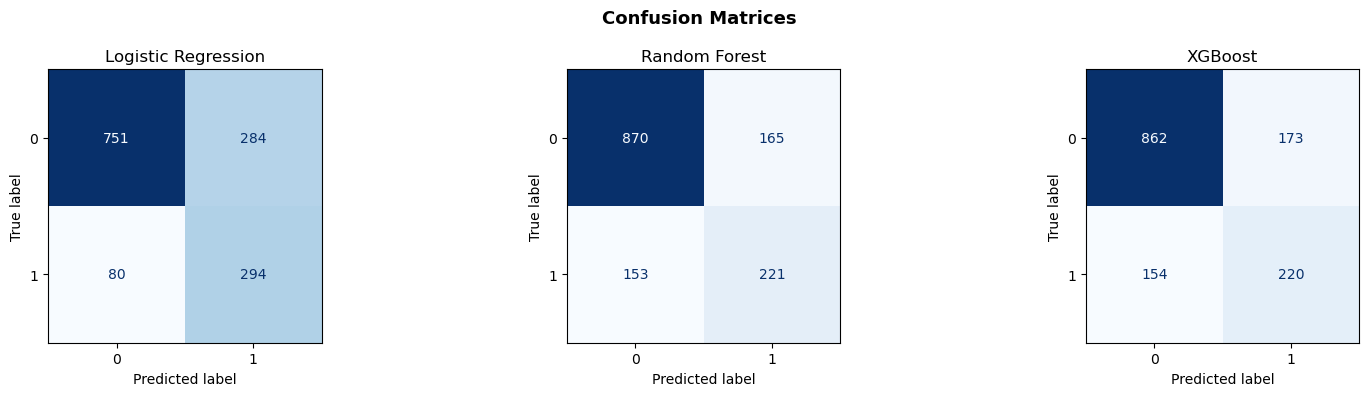

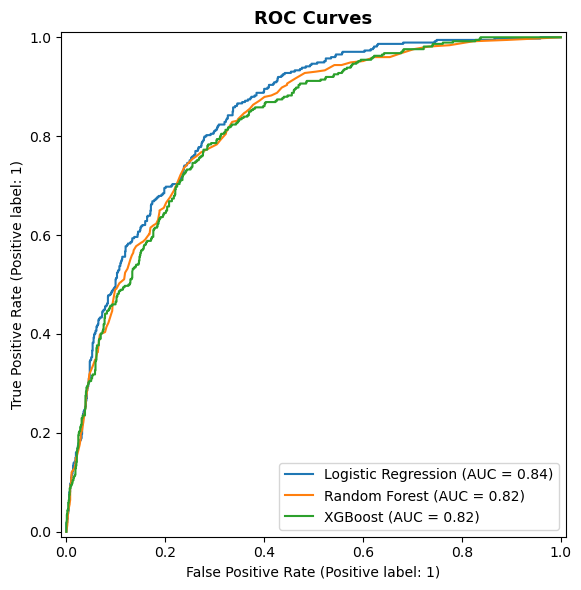

In [7]:
# -- 5. EVALUATE
results = evaluate_models(trained_models, X_test, y_test)

In [8]:
# -- 6. TUNE XGBOOST
best_xgb = tune_xgboost(X_train, y_train)


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}
Best CV AUC: 0.9344


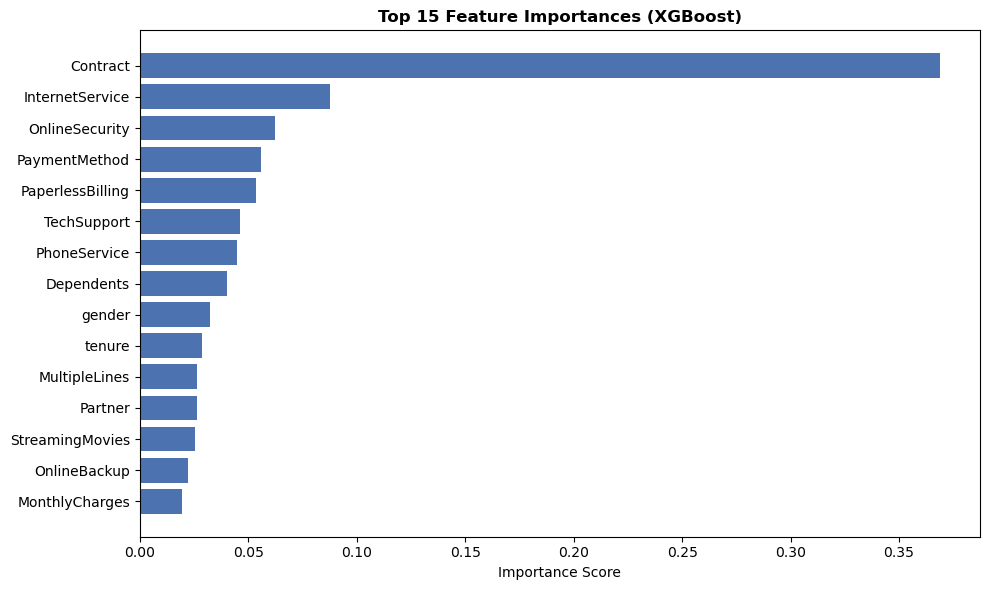

In [9]:
# -- 7. FEATURE IMPORTANCE
plot_feature_importance(best_xgb, X.columns.tolist())

In [10]:
# -- 8. SAVE BEST MODEL
save_model(best_xgb)

Model saved to models/churn_model.pkl
